In [5]:
#### Necessary libraries ####

import numpy as np  # Numpy is the fundamental package for scientific computing in Python.
import pandas as pd
from Functions import *
import pylab
from combine_data import read_data, read_precip_era5, read_tracked_precip
from paths import basedir, figure_path
from sklearn.cluster import KMeans
import seaborn as sns
from eofs.xarray import Eof #Import eofs package

# The statement below enforces the plots to be put into this notebook, instead of in their own windows.
%matplotlib inline

In [6]:
# Settings 
cases = ["Pakistan","Australia","Scotland"]

# TODO: fix WAM2layers units (?)
list_reordered = [
    "WAM2layers",
    "2LDRM",
    #'UTrack Ens1',
    "UTrack Ens2",
    #'UTrack Ens3',
    #'UTrack Ens4',
    #'UTrack Ens5',
    "BTrIMS",
    "TRACMASS",
    #'FLEXPART-HAMSTER Ens1',
    #'FLEXPART-HAMSTER Ens2',
    #'FLEXPART-HAMSTER Ens3',
    #'FLEXPART-HAMSTER Ens4',
    "FLEXPART-SSW08 (HAMSTER) Ens5",
    "FLEXPART-SSW08 (WaterSip)",
    "FLEXPART-SSW08 (UniVie)",
    "LAGRANTO-SSW08",
    "FLEXPART-SSW08 (IBCAS)",
    "FLEXPART-SSW08 (HKUST) Ens2",
    "FLEXPART-SSW08 (LATTIN)",
    #'WRF-WVT',
    "FLEXPART-SJ04 (LATTIN)",
]

# Data loading & Calculation of clusters

In [9]:
#Results storage
kmeans_results = {}
eofs_results = {}

# Loop over cases
for case in cases:
    print(f"Processing case: {case}")

    ########################################################
    ## import model runs                                  ##
    ########################################################
    ds_sources = read_data(basedir, case)

    ########################################################
    ## preprocess model runs                              ##
    ########################################################

    #### model runs for plotting ####
    all_maps = {kk: ds_sources[kk] for kk in list_reordered}
    all_maps = xr.Dataset(all_maps)

    #Select area of interest without nans
    if(case=="Pakistan"):
        #[20.0, 120.0, -30.0, 40.0]
        all_maps = all_maps.sel(lat=slice(-30, 40), lon=slice(20, 120))
    elif(case=="Australia"):
        #([-160.0, 180.0, -80.0, 20.0])
        all_maps = all_maps.sel(lat=slice(-80, 20), lon=slice(-160, 190))
    elif(case=="Scotland"):
        #[-100.0, 50.0, 5.0, 60.0]
        all_maps = all_maps.sel(lat=slice(5, 60), lon=slice(-100, 50))

    #Set nans to zero
    all_maps = all_maps.fillna(0)

    #Normalize data
    #all_maps_nonnormalized = all_maps.copy()
    #for model in all_maps.data_vars:
    #    data = all_maps[model].values
    #    data_min = np.min(data)
    #    data_max = np.max(data)
    #    all_maps[model].values = (data - data_min) / (data_max - data_min)
    
    ########################################################
    ## Clustering analysis                               ##
    ########################################################
    #Do a clustering analysis to group similar model runs together
    kmeans  = KMeans(n_clusters=3, random_state=12).fit(
        all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
            13, -1
        )
    )
    kmeans_results[case] = kmeans

    labels = kmeans.labels_
    for i, model in enumerate(all_maps.data_vars):
        print(f"{model}: Cluster {labels[i]}") 

    ########################################################
    ## EOF analysis                                     ##
    ########################################################
    #Do an EOF analysis to find dominant patterns in model runs
    #solver = Eof(all_maps.to_array().transpose("variable", "lat", "lon"))
    #eofs_results[case] = solver.eofsAsCorrelation(neofs=3)
    #pcs = solver.pcs(npcs=3, pcscaling=1)
    #var_frac = solver.varianceFraction(neigs=3)

Processing case: Pakistan
Loading WRF-WVT data for Pakistan
Loading wam2layers data for Pakistan
Loading 2ldrm data for Pakistan
Loading utrack data for Pakistan
Loading btrims data for Pakistan
Loading tracmass data for Pakistan
Loading ughent data for Pakistan
Loading UIB data for Pakistan
Loading UniVie data for Pakistan
Loading CHc data for Pakistan
Loading xu data for Pakistan
Loading tatfancheng data for Pakistan
Loading uvigo data for Pakistan


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


WAM2layers: Cluster 0
2LDRM: Cluster 0
UTrack Ens2: Cluster 0
BTrIMS: Cluster 0
TRACMASS: Cluster 1
FLEXPART-SSW08 (HAMSTER) Ens5: Cluster 0
FLEXPART-SSW08 (WaterSip): Cluster 1
FLEXPART-SSW08 (UniVie): Cluster 1
LAGRANTO-SSW08: Cluster 1
FLEXPART-SSW08 (IBCAS): Cluster 1
FLEXPART-SSW08 (HKUST) Ens2: Cluster 1
FLEXPART-SSW08 (LATTIN): Cluster 1
FLEXPART-SJ04 (LATTIN): Cluster 2
Processing case: Australia
Loading WRF-WVT data for Australia
Loading wam2layers data for Australia
Loading 2ldrm data for Australia
Loading utrack data for Australia
Loading btrims data for Australia
Loading tracmass data for Australia
Loading ughent data for Australia
Loading UIB data for Australia
Loading UniVie data for Australia
Loading CHc data for Australia
Loading xu data for Australia
Loading tatfancheng data for Australia
Loading uvigo data for Australia


c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


WAM2layers: Cluster 0
2LDRM: Cluster 0
UTrack Ens2: Cluster 0
BTrIMS: Cluster 0
TRACMASS: Cluster 0
FLEXPART-SSW08 (HAMSTER) Ens5: Cluster 0
FLEXPART-SSW08 (WaterSip): Cluster 0
FLEXPART-SSW08 (UniVie): Cluster 1
LAGRANTO-SSW08: Cluster 1
FLEXPART-SSW08 (IBCAS): Cluster 0
FLEXPART-SSW08 (HKUST) Ens2: Cluster 1
FLEXPART-SSW08 (LATTIN): Cluster 1
FLEXPART-SJ04 (LATTIN): Cluster 2
Processing case: Scotland
Loading WRF-WVT data for Scotland
Loading wam2layers data for Scotland
Loading 2ldrm data for Scotland
Loading utrack data for Scotland
Loading btrims data for Scotland
Loading tracmass data for Scotland
Loading ughent data for Scotland
Loading UIB data for Scotland
Loading UniVie data for Scotland
Loading CHc data for Scotland
Loading xu data for Scotland
Loading tatfancheng data for Scotland
Loading uvigo data for Scotland
WAM2layers: Cluster 0
2LDRM: Cluster 0
UTrack Ens2: Cluster 0
BTrIMS: Cluster 0
TRACMASS: Cluster 1
FLEXPART-SSW08 (HAMSTER) Ens5: Cluster 0
FLEXPART-SSW08 (WaterSi

c:\Users\chris\OneDrive\Documenten\Data\Moisture_tracking_intercomparison\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# PLOTS

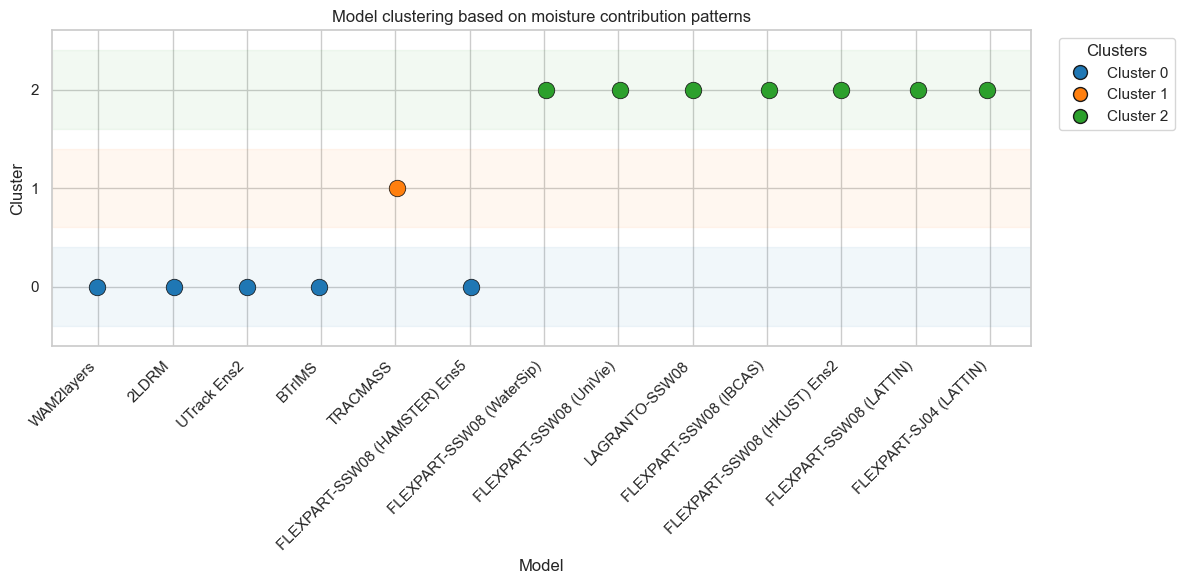

In [ ]:
#Make a plot to show which models are in which cluster for specific case
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 6))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
x = np.arange(len(all_maps.data_vars))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for i, model in enumerate(all_maps.data_vars):
    plt.scatter(i + jitter[i], labels[i], s=140,
                color=palette[labels[i]], edgecolor='k', linewidth=0.6)
# draw horizontal bands for each cluster
for cluster in np.unique(labels):
    plt.axhspan(cluster - 0.4, cluster + 0.4,
                color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, all_maps.data_vars, rotation=45, ha='right')
# show integer y ticks for cluster indices
plt.yticks(np.unique(labels))
plt.ylim(-0.6, np.max(labels) + 0.6)
plt.xlabel("Model")
plt.ylabel("Cluster")
plt.title("Model clustering based on moisture contribution patterns")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# save figure to figures path if available
try:
    plt.savefig(figure_path + '/cluster_assignment_' + case + '.png', dpi=150, bbox_inches='tight')
except Exception:
    pass
plt.show()


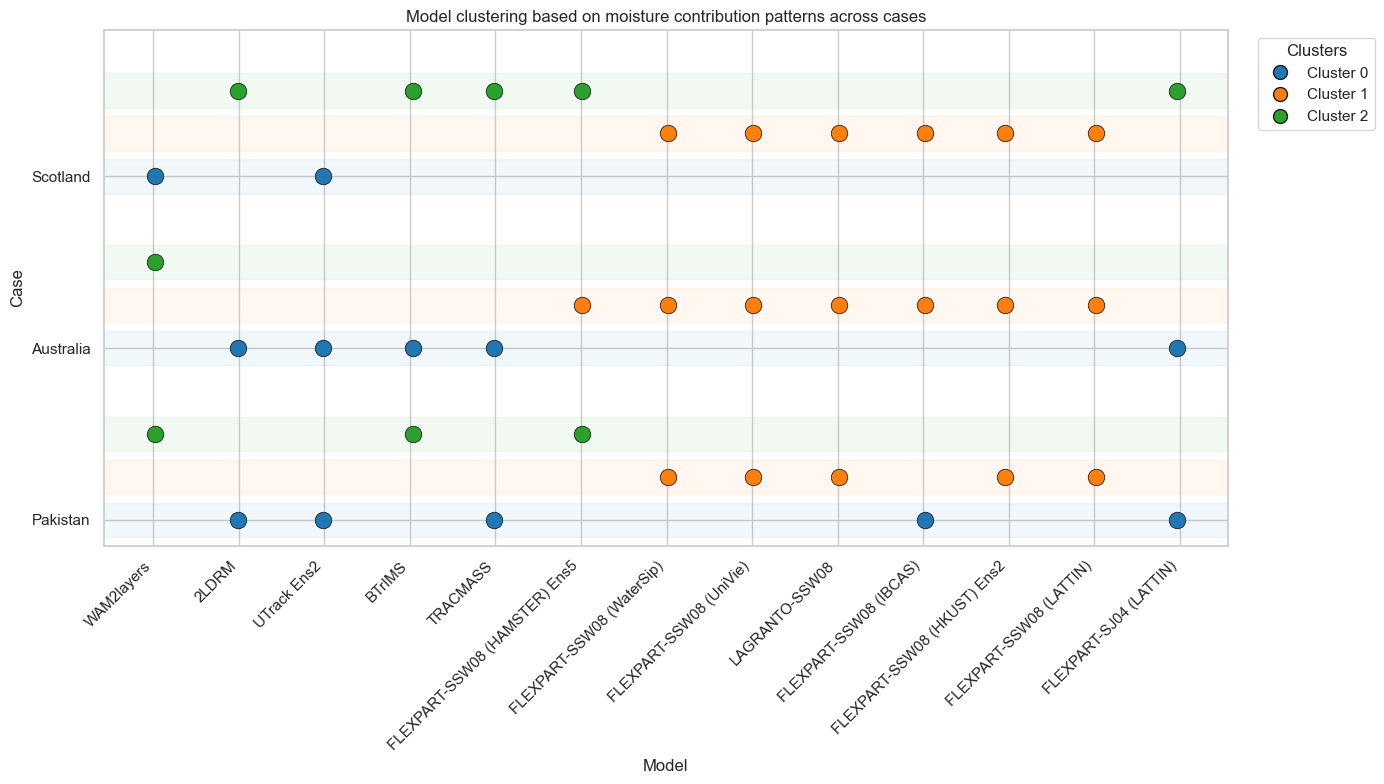

In [29]:
#Make a nicer plot to show which models are in which cluster for all cases
%matplotlib inline
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(14, 8))
# Colors for clusters
palette = sns.color_palette("tab10", n_colors=3)    
x = np.arange(len(list_reordered))
# add a small jitter so labels don't overlap
jitter = (np.random.rand(len(x)) - 0.5) * 0.08
for case in cases:          
    kmeans = kmeans_results[case]
    labels = kmeans.labels_
    for i, model in enumerate(list_reordered):
        plt.scatter(i + jitter[i], labels[i] + (cases.index(case) * 4), s=140,
                    color=palette[labels[i]], edgecolor='k', linewidth=0.6)
    # draw horizontal bands for each cluster
    for cluster in np.unique(labels):
        plt.axhspan(cluster - 0.4 + (cases.index(case) * 4),
                    cluster + 0.4 + (cases.index(case) * 4),
                    color=palette[cluster], alpha=0.06)

# Annotate model names below the x-axis and rotate
plt.xticks(x, list_reordered, rotation=45, ha='right')  
# show integer y ticks for cluster indices
plt.yticks(np.arange(0, len(cases) * 4, 4), cases)
plt.ylim(-0.6, len(cases) * 4 - 0.6)
plt.xlabel("Model") 
plt.ylabel("Case")
plt.title("Model clustering based on moisture contribution patterns across cases")
# build a compact legend showing cluster colors
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {c}',
                     markerfacecolor=palette[c], markersize=10, markeredgecolor='k')
           for c in np.unique(labels)]
plt.legend(handles=handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
# save figure to figures path if available
try:
    plt.savefig(figure_path + '/cluster_assignment_all_cases.png', dpi=150, bbox_inches='tight')
except Exception:
    pass    

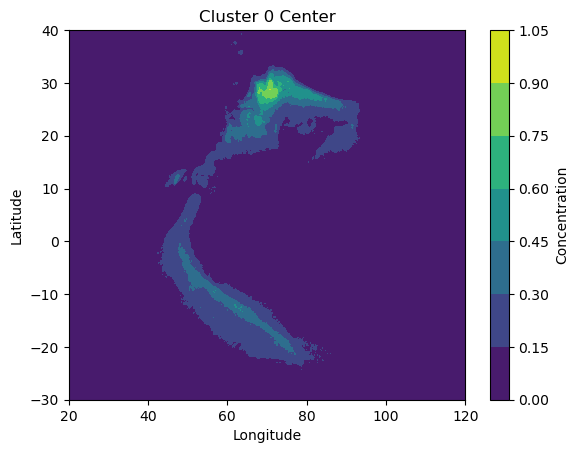

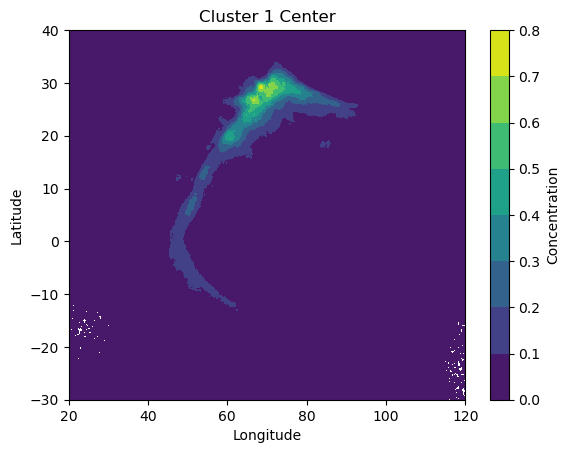

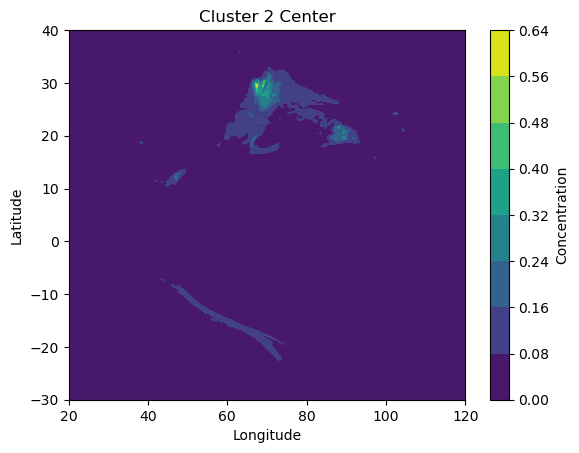

WAM2layers: Distances to centers [12.29447698 19.09131363 25.70050548]
2LDRM: Distances to centers [22.60168092 16.10604503 10.27338003]
UTrack Ens2: Distances to centers [24.05113891 14.98117044  5.05635107]
BTrIMS: Distances to centers [10.80008993 24.24913788 28.5061862 ]
TRACMASS: Distances to centers [30.67541461 18.88318407  7.83225743]
FLEXPART-SSW08 (HAMSTER) Ens5: Distances to centers [ 6.1438506  19.34562352 25.88909845]
FLEXPART-SSW08 (WaterSip): Distances to centers [16.68785557  9.38959652 22.53734265]
FLEXPART-SSW08 (UniVie): Distances to centers [20.479926    4.8696414  14.97904563]
LAGRANTO-SSW08: Distances to centers [15.7096797   7.89489056 18.75115738]
FLEXPART-SSW08 (IBCAS): Distances to centers [22.71347763  7.88102876 10.97777231]
FLEXPART-SSW08 (HKUST) Ens2: Distances to centers [22.6889178   6.79108071 12.50979418]
FLEXPART-SSW08 (LATTIN): Distances to centers [20.64423471  5.5409571  17.75544109]
FLEXPART-SJ04 (LATTIN): Distances to centers [21.31223293 12.6424

In [ ]:
# Calculate cluster centers
centers = kmeans.cluster_centers_.reshape(3, all_maps.lat.size, all_maps.lon.size)
# Plot cluster centers
for i, center in enumerate(centers):
    plt.figure()
    plt.contourf(all_maps.lon, all_maps.lat, center, cmap="viridis")
    plt.title(f"Cluster {i} Center")
    plt.colorbar(label="Concentration")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()


#Caclulate distances to cluster centers
distances = kmeans.transform(
    all_maps.to_array().transpose("variable", "lat", "lon").values.reshape(
        13, -1
    )
)   
for i, model in enumerate(all_maps.data_vars):
    dists = distances[i]
    print(f"{model}: Distances to centers {dists}")

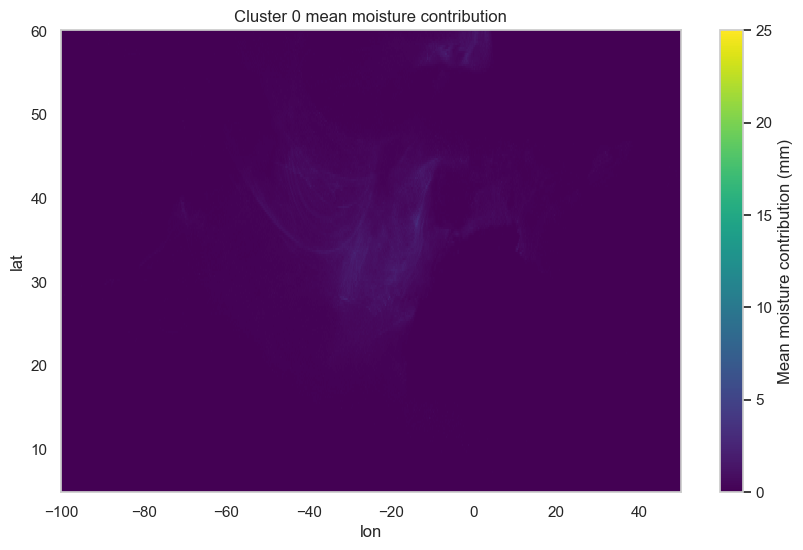

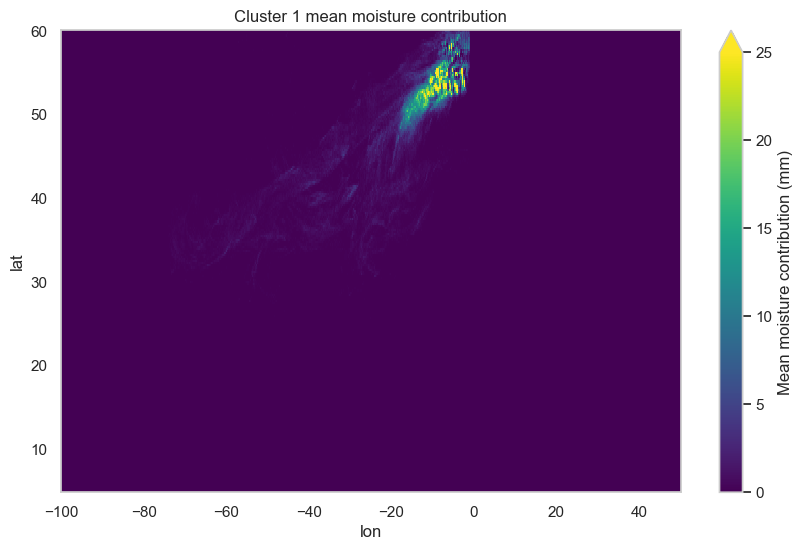

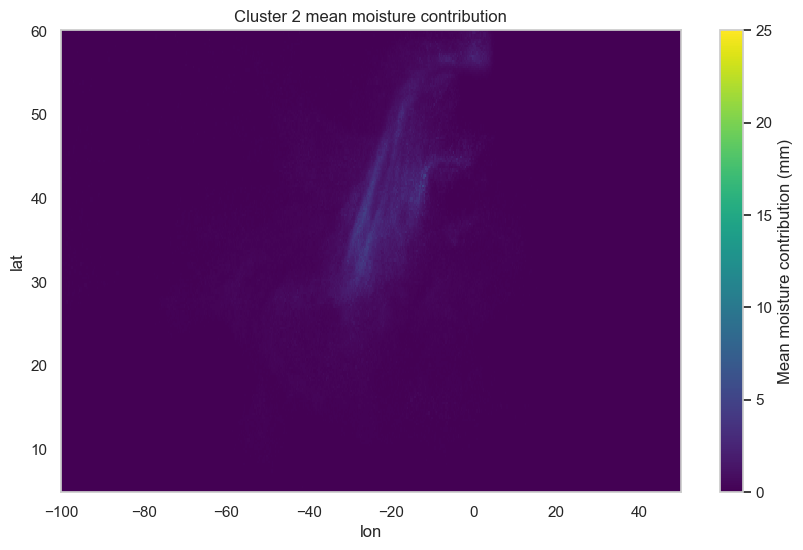

In [36]:
#Plot mean of different defined clusters
for cluster in np.unique(labels):
    plt.figure(figsize=(10, 6))
    cluster_members = [
        model
        for i, model in enumerate(all_maps.data_vars)
        if labels[i] == cluster
    ]
    cluster_mean = all_maps[cluster_members].to_array(dim='new').mean('new')
    cluster_mean.plot(
        cmap="viridis",
        vmin=0,
        vmax=25,
        cbar_kwargs={"label": "Mean moisture contribution (mm)"},
    )   

    plt.title(f"Cluster {cluster} mean moisture contribution")
    plt.show()

